# Merge MSOA and optimise on all groups

In [1]:
import os
import polars as pl
import numpy as np

from scipy.optimize import minimize
import statsmodels.api as sm  # for linear regression

import matplotlib.pyplot as plt

## Load data

Patient demographics by MSOA:

In [2]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [3]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662


Check sum of admissions for Welsh areas:

In [4]:
df_stats.filter(df_stats['country'] == 'W')['admissions'].sum()

0.0

Welsh data is always zero so remove it.

In [5]:
df_stats = df_stats.filter(df_stats['country'] != 'W')

Recalculate total numbers of patients:

In [6]:
df_stats = df_stats.with_columns((pl.col('good_health') + pl.col('fair health') + pl.col('bad health')).alias('total_health'))

In [7]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526


Pick out column names for the health and age proportions:

In [8]:
health_numbers = ['good_health', 'fair health', 'bad health']
props_health = ['prop_good_health', 'prop_fair health', 'prop_bad health']
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]

Calculate numbers of patients in each age band:

In [9]:
age_numbers = []

for col in props_age:
    new_col = col.replace('_proportion', '')
    age_numbers.append(new_col)
    df_stats = df_stats.with_columns((pl.col(col) * pl.col('total_health')).alias(new_col))

In [10]:
df_stats[['total_health'] + props_age + age_numbers].head()

total_health,age_less65_proportion,age_65_proportion,age_70_proportion,age_75_proportion,age_over80_proportion,age_less65,age_65,age_70,age_75,age_over80
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
8524,0.7872,0.0559,0.0528,0.0422,0.062,6710.0928,476.4916,450.0672,359.7128,528.488
6634,0.7467,0.0578,0.0774,0.0492,0.0692,4953.6078,383.4452,513.4716,326.3928,459.0728
7100,0.7729,0.0609,0.0582,0.0421,0.0661,5487.59,432.39,413.22,298.91,469.31
10127,0.8091,0.0465,0.0438,0.0367,0.0638,8193.7557,470.9055,443.5626,371.6609,646.1026
8526,0.7643,0.0597,0.067,0.0425,0.0662,6516.4218,509.0022,571.242,362.355,564.4212


## Set up bins for IMD scores

Use quantiles so that each bin contains 10% of the MSOA (to match plot notebook).

The resulting dictionary has keys for which quantile it is and values for the left side (smaller, minimum value in bin) of the IMD bin.

In [11]:
dict_quantiles = {}

for q in np.arange(0.0, 1.01, 0.2):
    v = df_stats['IMD2019Score'].quantile(q)
    # Flip the ranking because lower rank (more deprived) should be for
    # higher IMD scores (more deprived).
    q_store = 1.0 - q
    dict_quantiles[round(q_store, 1)] = round(v, 5)

In [12]:
dict_quantiles

{1.0: 2.2122,
 0.8: 10.369,
 0.6: 15.2564,
 0.4: 21.81475,
 0.2: 31.84075,
 0.0: 87.02675}

Pick out just the values for the left edges of the bins:

In [13]:
imd_bin_left_edges = {}
for k in list(dict_quantiles.keys())[:-1]:
    imd_bin_left_edges[k] = dict_quantiles[k]

In [14]:
imd_bin_left_edges

{1.0: 2.2122, 0.8: 10.369, 0.6: 15.2564, 0.4: 21.81475, 0.2: 31.84075}

Place MSOA into these bins:

In [15]:
# Make columns for the results with a placeholder value:
# df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_min'))
# df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_max'))
df_stats = df_stats.with_columns(pl.lit(0.0).alias('depriv_quantile_min'))
df_stats = df_stats.with_columns(pl.lit(0.0).alias('depriv_quantile_max'))

for q, quantile in enumerate(list(dict_quantiles.keys())[:-1]):
    # Pick out the bin edges:
    qmin = list(dict_quantiles.keys())[q+1]
    q0 = dict_quantiles[quantile]
    q1 = dict_quantiles[qmin]
    # Find a mask for the demographic data that contains
    # only MSOA with IMD scores in this bin.
    mask = (df_stats['IMD2019Score'] >= q0) & (df_stats['IMD2019Score'] < q1)
    if q == len(dict_quantiles) - 2:
        # Also allow values at the right edge of the final bin.
        mask = mask | (df_stats['IMD2019Score'] == q1)

    # Update the bin min/max values for these rows:
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(qmin)         # replace with bin min
        .otherwise(pl.col('depriv_quantile_min'))  # otherwise keep the existing value
        .name.keep()
    )
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(quantile)         # replace with bin min
        .otherwise(pl.col('depriv_quantile_max'))  # otherwise keep the existing value
        .name.keep()
    )

Check that data was binned correctly:

In [16]:
df_stats[['IMD2019Score', 'depriv_quantile_min', 'depriv_quantile_max']]

IMD2019Score,depriv_quantile_min,depriv_quantile_max
f64,f64,f64
16.924833,0.4,0.6
6.4704,0.8,1.0
13.7334,0.6,0.8
26.199857,0.2,0.4
11.7948,0.6,0.8
…,…,…
3.25925,0.8,1.0
7.29475,0.8,1.0
12.117,0.6,0.8


## Group LSOAs

In [17]:
def make_groups(df_here, n_groups=5):
    """Randomly assign groups."""
    # Setup:
    groups = np.zeros(len(df_here), dtype=int)
    inds_available = np.arange(len(df_here))
    
    # n_groups = 104  # 271  # 104
    group_sizes = int(len(df_here)/n_groups)
    group_extra = len(df_here) - ((n_groups - 1) * group_sizes)
    print(len(df_here), group_sizes, group_extra)

    # Assign groups:
    for g in range(n_groups):
        group_size = group_sizes if g < (n_groups - 1) else group_extra
        inds = np.random.choice(inds_available, size=group_size, replace=False)
        groups[inds] = g
        inds_available = list(set(inds_available) - set(inds))
    # Include results in starting dataframe:
    df_here = df_here.with_columns(pl.Series('group', groups))
    return df_here

In [18]:
def glob_msoa(df_here):
    dfs_to_glob = []
    
    cols_to_keep = ['admissions', 'All persons', 'age_less65', 'age_65', 'age_70', 'age_75', 'age_over80']
    
    for g in sorted(df_here['group'].unique().to_numpy()):
        df_sum = df_here.filter(df_here['group'] == g).sum()
        # Only keep some columns:
        df_sum = df_sum[cols_to_keep]
        dfs_to_glob.append(df_sum)
    
    df_group_sums = pl.concat(dfs_to_glob)
    # Add label for group names:
    df_group_sums = df_group_sums.with_columns(pl.Series('group_label', np.arange(len(df_group_sums))))
    return df_group_sums

In [20]:
dict_group_sums = {}

np.random.seed(42)

for qmin in np.arange(0.0, 1.0, 0.2):
    df_here = df_stats.filter(np.round(df_stats['depriv_quantile_min'], 1) == round(qmin, 1))
    # Aim for 5 MSOA per group:
    group_sizes = 5
    n_groups = int(len(df_here) / group_sizes)
    df_here = make_groups(df_here, n_groups)
    # Gather data for these groups:
    df_group_sums = glob_msoa(df_here)
    # Store results:
    dict_group_sums[qmin] = df_group_sums

1359 271 275
1358 271 274
1357 271 273
1358 271 274
1358 271 274


In [21]:
for qmin, df in dict_group_sums.items():
    print(qmin)
    display(df)

0.0


admissions,All persons,age_less65,age_65,age_70,age_75,age_over80,group_label
f64,i64,f64,f64,f64,f64,f64,i64
3045.666667,2234027,1.8162e6,82612.1409,73728.0431,51066.5425,73080.3317,0
3349.0,2315764,1.8707e6,87362.7368,79009.4604,55132.0011,78235.8228,1
3239.0,2305841,1.8603e6,84252.5536,74841.7558,52110.4273,74099.4123,2
3351.0,2300656,1.8661e6,87227.7983,79545.6711,54375.6166,78009.4704,3
3435.666667,2318608,1.8762e6,90486.0684,81715.5864,56432.499,81084.7982,4


0.2


admissions,All persons,age_less65,age_65,age_70,age_75,age_over80,group_label
f64,i64,f64,f64,f64,f64,f64,i64
3316.333333,2336094,1.8279e6,98051.0155,94549.4521,66545.6415,94870.0014,0
3250.0,2268263,1.7661e6,96372.9766,93280.0384,66584.0641,94336.2711,1
3256.0,2304752,1.8095e6,98993.1796,96659.0089,67923.5076,96510.3785,2
3136.666667,2285541,1.8139e6,95898.4897,91971.0771,64610.045,90069.6093,3
3245.0,2244919,1.7696e6,96521.322,93199.3002,66254.066,95143.9858,4


0.4


admissions,All persons,age_less65,age_65,age_70,age_75,age_over80,group_label
f64,i64,f64,f64,f64,f64,f64,i64
3305.666667,2259328,1.7028e6,111405.4446,114455.578,81466.6125,114301.0273,0
3304.333333,2244459,1.7029e6,112343.4819,114514.5212,80896.5885,112795.0641,1
3324.0,2210320,1.6650e6,111929.9802,116199.9903,83853.6601,116692.9001,2
3184.333333,2245061,1.7176e6,109511.3511,111060.7973,78684.5276,111752.2138,3
3323.666667,2241195,1.7042e6,113355.3829,115181.3762,81617.5124,113630.1362,4


0.6000000000000001


admissions,All persons,age_less65,age_65,age_70,age_75,age_over80,group_label
f64,i64,f64,f64,f64,f64,f64,i64
3273.0,2222434,1.6468e6,116746.64,123690.1574,88657.6374,126314.2982,0
3338.333333,2200551,1.6384e6,118109.0155,124458.6063,89489.2166,126746.2171,1
3212.333333,2137529,1.5942e6,116900.4282,123674.7342,88872.6037,122659.1316,2
3274.0,2176667,1.6218e6,119181.2861,126213.9796,91383.0522,127599.6364,3
3321.333333,2175098,1.6234e6,121200.9757,127311.5142,92680.9113,128562.2854,4


0.8


admissions,All persons,age_less65,age_65,age_70,age_75,age_over80,group_label
f64,i64,f64,f64,f64,f64,f64,i64
2985.666667,2196417,1.6476e6,112671.5664,122453.8456,89088.5408,127832.1953,0
3226.666667,2195472,1.6317e6,118709.3696,129412.5867,94060.1321,136981.0019,1
3130.333333,2161354,1.6050e6,116476.4416,125581.8421,91596.4578,136116.7023,2
2966.333333,2169301,1.6203e6,114213.4375,122368.4902,89238.8198,126094.924,3
3163.666667,2225285,1.6564e6,115016.4608,124059.6315,91495.4721,133667.8017,4


In [22]:
qmin_list = list(dict_group_sums.keys())

## Function for optimising

In [101]:
def main_opt(coeffs, args):
    all_calculated_admissions = []
    all_observed_admissions = sum([list(a) for a in args[1]], [])

    coeffs_grid = np.array(coeffs).reshape(5, 5)
    for i, q in enumerate(qmin_list):
        coeffs_q = coeffs_grid[i, :]
        x_lists = args[0][i]
        admissions = args[1][i]
        
        calculated_admissions = predict_admissions(x_lists, np.array(coeffs_q))

        all_calculated_admissions += list(calculated_admissions)

    # Calculate measure of difference from the observed admissions:
    # print(
    #     np.array(all_calculated_admissions),
    #     np.array(all_observed_admissions)
    # )
    # diff = find_mean_abs_diff(
    diff = find_square_residuals(
        np.array(all_calculated_admissions),
        np.array(all_observed_admissions)
    )
    use_penalty = True
    if use_penalty:
        # Check coefficient conditions. If any aren't met, add a penalty
        # to the main difference measure.
        n_decrease = 0.0
        for i, q in enumerate(qmin_list):
            # Pick out coeffs for this depriv quantile:
            coeffs_q = coeffs_grid[i, :]
            # Do all coeffs increase with age band?
            n_decrease += sum(np.sign(np.diff(coeffs_q)) < 0)
        # Add penalty:
        if n_decrease > 0.0:
            diff += (n_decrease * 0.2 * abs(diff))

        n_increase = 0.0
        for i, a in enumerate(age_numbers):
            # Pick out coeffs for this age band:
            coeffs_q = coeffs_grid[:, i]
            # Do all coeffs decrease with depriv quantile?
            n_increase += sum(np.sign(np.diff(coeffs_q)) > 0)
        # Add penalty:
        if n_increase > 0.0:
            diff += (n_increase * 0.2 * abs(diff))
    # print(coeffs_grid)
    # print(n_decrease, n_increase, diff)
    # print('\n' * 3)
    return diff

In [30]:
def predict_admissions(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    return yhat

Goodness check option 1: This calculates the sum of the square of the differences between predicted and actual admission numbers:

In [70]:
def find_square_residuals(yhat, y):
    # Difference from actual:
    sqres = (yhat - y)**2.0
    # Sum of differences:
    sum_sqres = np.sqrt(sqres.sum())
    return sum_sqres

Goodness check option 2: This calculates the mean absolute difference between the predicted and real admissions numbers:

In [32]:
def find_mean_abs_diff(yhat, y):
    # Difference from actual:
    absres = np.abs((yhat - y))
    # Mean of differences:
    mean_absres = absres.mean()
    return mean_absres

To check accuracy, the following function calculates R-squared:

In [33]:
def calculate_rsquared(y, yhat):
    """This gives the same results as the sklearn built-in."""
    y_mean = y.mean()
    ss_res = ((yhat - y)**2.0).sum()
    ss_tot = ((y - y_mean)**2.0).sum()
    if ss_tot != 0.0:
        rsq = 1.0 - ss_res / ss_tot
    else:
        rsq = np.NaN
    return rsq

## Optimise:

In [2]:
# coeffs_init = [4e-4, 5e-4, 2e-3, 6e-3, 1.7e-2]
# coeffs_init = [4e-4, 5e-4, 7e-4, 7e-4, 1.5e-2]
# coeffs_init = [3e-4, 2e-3, 3e-3, 4e-3, 8e-3]
coeffs_ssnap = [0.000408, 0.002644, 0.003735, 0.006005, 0.011558]

# coeffs_init = coeffs_ssnap * 5

coeffs_init = list(np.concatenate((
    np.array(coeffs_ssnap) * 1.2,
    np.array(coeffs_ssnap) * 1.1,
    np.array(coeffs_ssnap) * 1.0,
    np.array(coeffs_ssnap) * 0.9,
    np.array(coeffs_ssnap) * 0.8,
)))

coeffs_init

[0.0004896,
 0.0031728,
 0.004482,
 0.007206,
 0.013869600000000001,
 0.0004488,
 0.0029084000000000002,
 0.0041085,
 0.0066055,
 0.0127138,
 0.000408,
 0.002644,
 0.003735,
 0.006005,
 0.011558,
 0.0003672,
 0.0023796,
 0.0033615,
 0.0054045000000000004,
 0.0104022,
 0.0003264,
 0.0021152000000000002,
 0.002988,
 0.004804,
 0.0092464]

In [3]:
coeffs_init_grid = np.array(coeffs_init).reshape(5, 5)

In [4]:
coeffs_init_grid

array([[0.0004896, 0.0031728, 0.004482 , 0.007206 , 0.0138696],
       [0.0004488, 0.0029084, 0.0041085, 0.0066055, 0.0127138],
       [0.000408 , 0.002644 , 0.003735 , 0.006005 , 0.011558 ],
       [0.0003672, 0.0023796, 0.0033615, 0.0054045, 0.0104022],
       [0.0003264, 0.0021152, 0.002988 , 0.004804 , 0.0092464]])

In [5]:
coeffs_init_grid[:, 0]

array([0.0004896, 0.0004488, 0.000408 , 0.0003672, 0.0003264])

In [6]:
coeffs_init_grid[0, :]

array([0.0004896, 0.0031728, 0.004482 , 0.007206 , 0.0138696])

In [102]:

bounds_here = [(0.0, 1.0)] * len(coeffs_init)  # force results to lie between 0 and 1

all_x_lists = []
all_admissions = []
for qmin, df_group_sums in dict_group_sums.items():
    # MSOA data in the same order as those coefficients:
    x_lists = [df_group_sums[a] for a in age_numbers]
    admissions = df_group_sums['admissions'].to_numpy()
    all_x_lists.append(x_lists)
    all_admissions.append(admissions)

# Run the optimiser:
opt_results = minimize(
    main_opt,
    x0=coeffs_init,
    args=[all_x_lists, all_admissions],
    bounds=bounds_here,
    method='Nelder-Mead'
    # method='SLSQP',
)
# Pick out the resulting health coefficients:
coeffs = opt_results['x']

Check result:

In [103]:
opt_results

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 183.36336806542562
             x: [ 4.918e-04  3.059e-03 ...  5.578e-03  1.198e-02]
           nit: 3530
          nfev: 4654
 final_simplex: (array([[ 4.918e-04,  3.059e-03, ...,  5.578e-03,
                         1.198e-02],
                       [ 4.918e-04,  3.059e-03, ...,  5.578e-03,
                         1.198e-02],
                       ...,
                       [ 4.918e-04,  3.059e-03, ...,  5.579e-03,
                         1.198e-02],
                       [ 4.918e-04,  3.059e-03, ...,  5.578e-03,
                         1.198e-02]]), array([ 1.834e+02,  1.834e+02, ...,  1.834e+02,  1.834e+02]))

In [105]:
coeffs_init_grid

array([[0.0004896, 0.0031728, 0.004482 , 0.007206 , 0.0138696],
       [0.0004488, 0.0029084, 0.0041085, 0.0066055, 0.0127138],
       [0.000408 , 0.002644 , 0.003735 , 0.006005 , 0.011558 ],
       [0.0003672, 0.0023796, 0.0033615, 0.0054045, 0.0104022],
       [0.0003264, 0.0021152, 0.002988 , 0.004804 , 0.0092464]])

In [112]:
coeffs_init_grid[0, :]

array([0.00049183, 0.00305862, 0.00462389, 0.00945032, 0.01610601])

In [106]:
coeffs_ssnap

[0.000408, 0.002644, 0.003735, 0.006005, 0.011558]

In [104]:
coeffs.reshape(5, 5)

array([[0.00049183, 0.00305862, 0.00462389, 0.00945032, 0.01610601],
       [0.00042489, 0.00281324, 0.00372096, 0.00609213, 0.01538321],
       [0.00039448, 0.00218178, 0.00372096, 0.00590925, 0.01290729],
       [0.00039448, 0.00204174, 0.00306873, 0.00558008, 0.0119854 ],
       [0.00030763, 0.00124942, 0.00286133, 0.00557841, 0.01198057]])

In [107]:
results_calculated_admissions = []
# all_observed_admissions = sum([list(a) for a in all_admissions], [])

coeffs_grid = np.array(coeffs).reshape(5, 5)
for i, q in enumerate(qmin_list):
    coeffs_q = coeffs_grid[i, :]
    x_lists = all_x_lists[i]
    admissions = all_admissions[i]
    
    calculated_admissions = predict_admissions(x_lists, np.array(coeffs_q))

    results_calculated_admissions.append(calculated_admissions)

In [108]:
for i, qmin in enumerate(qmin_list):
    r2 = calculate_rsquared(all_admissions[i], results_calculated_admissions[i])
    print(r2)

0.8592523265789909
0.6464602453806156
0.6805925922352987
0.5813152753380446
0.8762789468885351


In [109]:
q_colours = plt.get_cmap('viridis')(np.linspace(0.0, 1.0, len(qmin_list)))

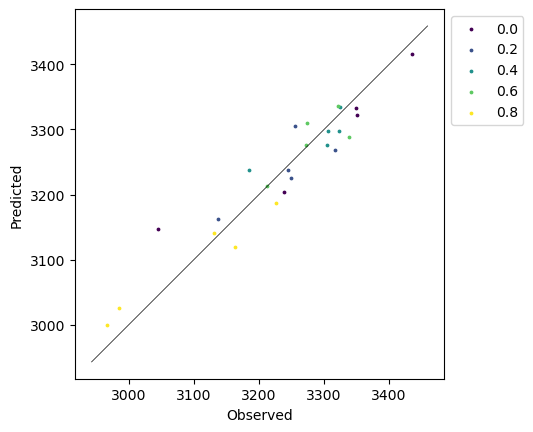

In [110]:
fig, ax = plt.subplots()

for i, qmin in enumerate(qmin_list):
    ax.scatter(all_admissions[i], results_calculated_admissions[i], s=3, color=q_colours[i], label=round(qmin, 1))

zmax = max([ax.get_xlim()[1], ax.get_ylim()[1]])
zmin = min([ax.get_xlim()[0], ax.get_ylim()[0]])
ax.plot([zmin, zmax], [zmin, zmax], color='k', linewidth=0.5)

ax.set_xlabel('Observed')
ax.set_ylabel('Predicted')

ax.set_aspect('equal')
ax.legend(bbox_to_anchor=[1.0, 1.0], loc='upper left')

plt.show()

0.42874948264504364
0.5706128560696108
0.633152960552172
0.5801007650015308
0.5417628260964811


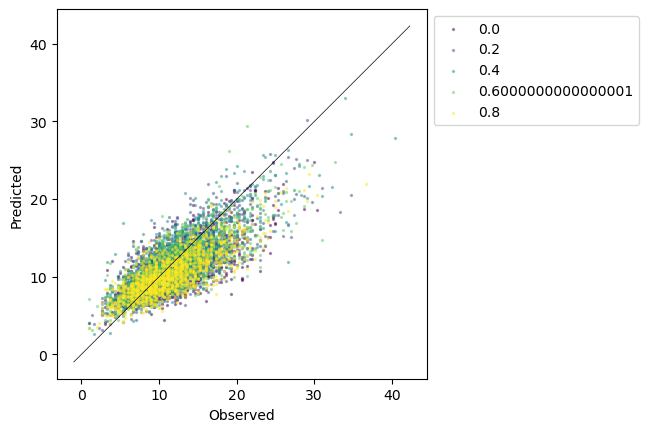

In [119]:
fig, ax = plt.subplots()

for i, qmin in enumerate(qmin_list):
    df_here = df_stats.filter(np.round(df_stats['depriv_quantile_min'], 1) == round(qmin, 1))
    coeffs_here = coeffs_init_grid[i, :]
    x_lists = [df_here[a] for a in age_numbers]
    predicted_admissions_here = predict_admissions(x_lists, np.array(coeffs_here))

    ax.scatter(df_here['admissions'], predicted_admissions_here, color=q_colours[i], label=qmin, alpha=0.4, s=2)
    
    r2 = calculate_rsquared(df_here['admissions'], predicted_admissions_here)
    print(r2)

zmax = max([ax.get_xlim()[1], ax.get_ylim()[1]])
zmin = min([ax.get_xlim()[0], ax.get_ylim()[0]])
ax.plot([zmin, zmax], [zmin, zmax], color='k', linewidth=0.5)

ax.set_xlabel('Observed')
ax.set_ylabel('Predicted')

ax.set_aspect('equal')
ax.legend(bbox_to_anchor=[1.0, 1.0], loc='upper left')

plt.show()

In [34]:
set_option = df_complete_sets.sort('rsquared_combo_set', descending=True)['set_option'][0]

row_set = df_complete_sets.filter(df_complete_sets['set_option'] == set_option)

row0 = df_here.filter((df_here['start_option'] == row_set['start_option_q00']) & (df_here['depriv_quantile_min'] == quantile_min_list[0]))
row1 = df_here.filter((df_here['start_option'] == row_set['start_option_q02']) & (df_here['depriv_quantile_min'] == quantile_min_list[1]))
row2 = df_here.filter((df_here['start_option'] == row_set['start_option_q04']) & (df_here['depriv_quantile_min'] == quantile_min_list[2]))
row3 = df_here.filter((df_here['start_option'] == row_set['start_option_q06']) & (df_here['depriv_quantile_min'] == quantile_min_list[3]))
row4 = df_here.filter((df_here['start_option'] == row_set['start_option_q08']) & (df_here['depriv_quantile_min'] == quantile_min_list[4]))

df_best_set_combo_r2 = pl.concat((row0, row1, row2, row3, row4))

display(df_best_set_combo_r2)

start_option,depriv_quantile_min,depriv_quantile_max,coeff_age_less65,coeff_age_65,coeff_age_70,coeff_age_75,coeff_age_over80,rsquared,rsquared_prop,rsquared_prop_minus
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
86173,0.0,0.2,0.0006,0.003,0.004,0.005,0.017,0.496213,0.992539,0.003539
73589,0.2,0.4,0.0005,0.002,0.003,0.004,0.017,0.582614,0.996339,0.001339
61013,0.4,0.6,0.0004,0.001,0.002,0.004,0.017,0.645111,0.999442,0.003442
61011,0.6,0.8,0.0004,0.001,0.002,0.004,0.015,0.615163,1.0,0.003
49483,0.8,1.0,0.0003,0.001,0.002,0.003,0.015,0.628031,0.99963,0.00463


In [120]:
coeffs_grid

array([[0.00049183, 0.00305862, 0.00462389, 0.00945032, 0.01610601],
       [0.00042489, 0.00281324, 0.00372096, 0.00609213, 0.01538321],
       [0.00039448, 0.00218178, 0.00372096, 0.00590925, 0.01290729],
       [0.00039448, 0.00204174, 0.00306873, 0.00558008, 0.0119854 ],
       [0.00030763, 0.00124942, 0.00286133, 0.00557841, 0.01198057]])

In [115]:
coeffs_init_grid[0, :]

array([0.0004896, 0.0031728, 0.004482 , 0.007206 , 0.0138696])

In [121]:
coeffs_ssnap

[0.000408, 0.002644, 0.003735, 0.006005, 0.011558]

In [8]:
coeffs_grid = np.array([[0.00049183, 0.00305862, 0.00462389, 0.00945032, 0.01610601],
       [0.00042489, 0.00281324, 0.00372096, 0.00609213, 0.01538321],
       [0.00039448, 0.00218178, 0.00372096, 0.00590925, 0.01290729],
       [0.00039448, 0.00204174, 0.00306873, 0.00558008, 0.0119854 ],
       [0.00030763, 0.00124942, 0.00286133, 0.00557841, 0.01198057]])

In [11]:
np.round(coeffs_grid / coeffs_ssnap, 2)

array([[1.21, 1.16, 1.24, 1.57, 1.39],
       [1.04, 1.06, 1.  , 1.01, 1.33],
       [0.97, 0.83, 1.  , 0.98, 1.12],
       [0.97, 0.77, 0.82, 0.93, 1.04],
       [0.75, 0.47, 0.77, 0.93, 1.04]])

In [10]:
coeffs_grid[1] / coeffs_ssnap

array([1.04139706, 1.06400908, 0.99624096, 1.01450958, 1.33095778])